# Подготовка данных

In [36]:
import pandas as pd
import pandas as pd
import networkx as nx
import community.community_louvain as community_louvain
import matplotlib.patches as mpatches
from matplotlib.patches import Circle

In [37]:
friday_url = "https://github.com/ekttd/VAST-Challenge/raw/main/MC2%202015%20Data/comm-data-Fri.csv"
df_fri = pd.read_csv(friday_url)
df_fri.head()

,Timestamp,from,to,location
0,2014-6-06 08:03:19,439105,1053224,Kiddie Land
1,2014-6-06 08:03:19,439105,1696241,Kiddie Land
2,2014-6-06 08:03:19,439105,580064,Kiddie Land
3,2014-6-06 08:03:19,439105,1464748,Kiddie Land
4,2014-6-06 08:03:47,1836139,1593258,Entry Corridor


In [38]:
saturday_url = "https://github.com/ekttd/VAST-Challenge/raw/main/MC2%202015%20Data/comm-data-Sat.csv"
df_sat = pd.read_csv(saturday_url)
df_sat.head()

,Timestamp,from,to,location
0,2014-6-07 08:01:58,1003120,839736,Entry Corridor
1,2014-6-07 08:02:01,1743218,1202957,Entry Corridor
2,2014-6-07 08:02:39,1760095,external,Entry Corridor
3,2014-6-07 08:02:40,686125,839736,Entry Corridor
4,2014-6-07 08:02:45,2046019,269197,Entry Corridor


In [39]:
sunday_url = "https://github.com/ekttd/VAST-Challenge/raw/main/MC2%202015%20Data/comm-data-Sun.csv"
df_sun = pd.read_csv(sunday_url)
df_sun.head()

,Timestamp,from,to,location
0,2014-6-08 08:01:05,1401601,839736,Kiddie Land
1,2014-6-08 08:01:16,1169163,600636,Entry Corridor
2,2014-6-08 08:01:16,1169163,1561994,Entry Corridor
3,2014-6-08 08:01:16,1169163,864634,Entry Corridor
4,2014-6-08 08:01:16,1169163,577530,Entry Corridor


In [40]:
import matplotlib.pyplot as plt
import numpy as np

In [41]:
# Функция для преобразования одного дня
def prepare_day_data(df_day, day_name):
    """Преобразует данные одного дня, добавляя quarter от начала дня"""
    df = df_day.copy()

    # Преобразуем Timestamp
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])

    # Начало дня (00:00 этого дня)
    day_start = pd.Timestamp(f"{df['Timestamp'].dt.date.iloc[0]} 00:00:00")

    # Минуты от начала дня
    minutes_from_start = (df['Timestamp'] - day_start).dt.total_seconds() // 60

    # Номер 15-минутного интервала (1-96)
    df['quarter'] = (minutes_from_start // 15 + 1).astype(int)

    # Добавляем час и минуту
    df['hour'] = df['Timestamp'].dt.hour
    df['minute'] = df['Timestamp'].dt.minute

    # Удаляем Timestamp (как в исходном коде)
    df = df.drop(columns=['Timestamp'])

    return df

In [42]:
# Преобразуем каждый день отдельно

df_fri_processed = prepare_day_data(df_fri, 'Friday')
df_sat_processed = prepare_day_data(df_sat, 'Saturday')
df_sun_processed = prepare_day_data(df_sun, 'Sunday')

print("Пятница (первые 5 строк):")
print(df_fri_processed.head())
print("\nСуббота (первые 5 строк):")
print(df_sat_processed.head())
print("\nВоскресенье (первые 5 строк):")
print(df_sun_processed.head())

Пятница (первые 5 строк):
      from       to        location  quarter  hour  minute
0   439105  1053224     Kiddie Land       33     8       3
1   439105  1696241     Kiddie Land       33     8       3
2   439105   580064     Kiddie Land       33     8       3
3   439105  1464748     Kiddie Land       33     8       3
4  1836139  1593258  Entry Corridor       33     8       3

Суббота (первые 5 строк):
      from        to        location  quarter  hour  minute
0  1003120    839736  Entry Corridor       33     8       1
1  1743218   1202957  Entry Corridor       33     8       2
2  1760095  external  Entry Corridor       33     8       2
3   686125    839736  Entry Corridor       33     8       2
4  2046019    269197  Entry Corridor       33     8       2

Воскресенье (первые 5 строк):
      from       to        location  quarter  hour  minute
0  1401601   839736     Kiddie Land       33     8       1
1  1169163   600636  Entry Corridor       33     8       1
2  1169163  1561994  Entr

# Паттерн общей активности в течение дня

In [43]:
# Получаем количество сообщений по интервалам для каждого дня

# Для пятницы
fri_quarters = df_fri_processed['quarter'].value_counts().sort_index()
# Заполняем все 96 интервалов
all_quarters = range(1, 97)
fri_counts = fri_quarters.reindex(all_quarters, fill_value=0)

# Для субботы
sat_quarters = df_sat_processed['quarter'].value_counts().sort_index()
sat_counts = sat_quarters.reindex(all_quarters, fill_value=0)

# Для воскресенья
sun_quarters = df_sun_processed['quarter'].value_counts().sort_index()
sun_counts = sun_quarters.reindex(all_quarters, fill_value=0)

# Создаем подписи времени (каждые 2 часа)
time_labels = []
for hour in range(0, 24, 2):
    time_labels.append(f"{hour:02d}:00")

In [44]:
# Для каждого дня нормализуем относительно его собственного максимума
fri_norm = fri_counts.values / fri_counts.max() if fri_counts.max() > 0 else fri_counts.values
sat_norm = sat_counts.values / sat_counts.max() if sat_counts.max() > 0 else sat_counts.values
sun_norm = sun_counts.values / sun_counts.max() if sun_counts.max() > 0 else sun_counts.values

print(f"Пятница: макс={fri_counts.max()}, мин={fri_counts.min()}")
print(f"Суббота: макс={sat_counts.max()}, мин={sat_counts.min()}")
print(f"Воскресенье: макс={sun_counts.max()}, мин={sun_counts.min()}")

Пятница: макс=27227, мин=0
Суббота: макс=44068, мин=0
Воскресенье: макс=65454, мин=0


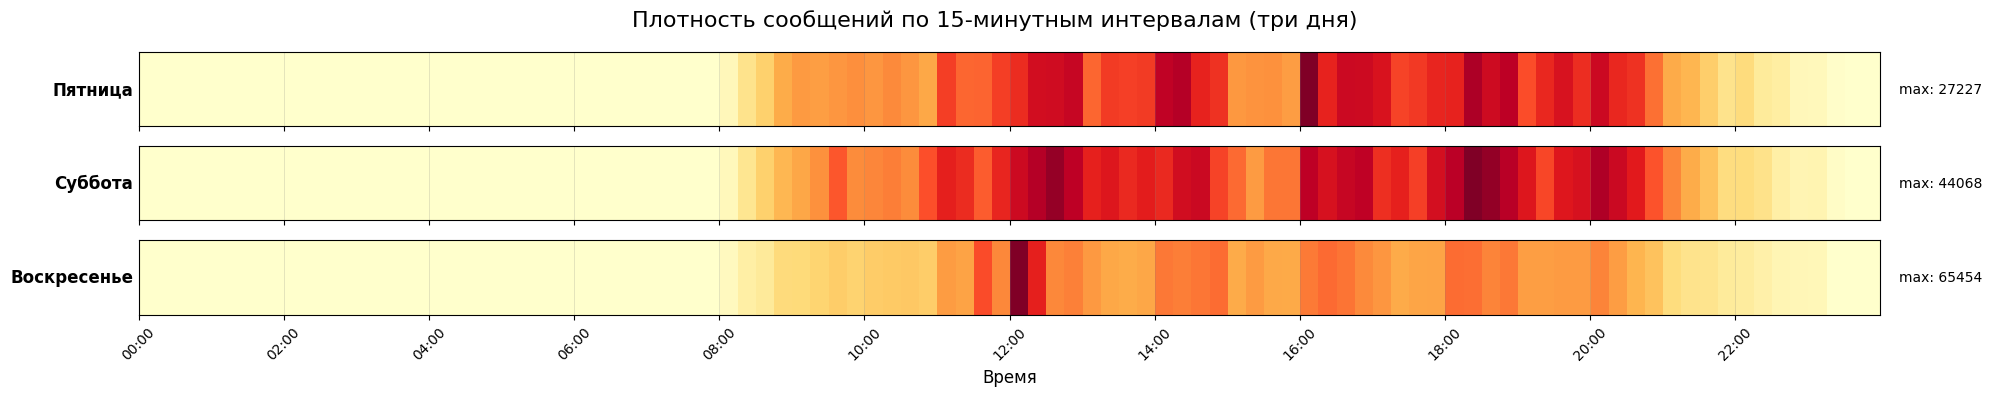

In [45]:
fig, axes = plt.subplots(3, 1, figsize=(20, 4), sharex=True)

days_data = [
    ('Пятница', fri_norm, fri_counts, axes[0], 'YlOrRd'),
    ('Суббота', sat_norm, sat_counts, axes[1], 'YlOrRd'),
    ('Воскресенье', sun_norm, sun_counts, axes[2], 'YlOrRd')
]

for i, (day_name, norm_data, counts, ax, cmap) in enumerate(days_data):
    # Отображаем как строку цветных квадратов
    im = ax.imshow([norm_data], cmap=cmap, aspect='auto', extent=[1, 97, 0, 1])

    # Настройка подписей
    ax.set_yticks([])
    ax.set_ylabel(day_name, fontsize=12, fontweight='bold', rotation=0, ha='right', va='center')

    # Добавляем значение максимума справа
    ax.text(98, 0.5, f"max: {counts.max()}", va='center', fontsize=10)

    # Вертикальные линии для разделения часов
    for hour in range(0, 25, 2):
        quarter_pos = hour * 4 + 1
        if quarter_pos <= 97:
            ax.axvline(x=quarter_pos, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

# Настройка нижней оси
axes[2].set_xticks([1 + i*8 for i in range(12)])
axes[2].set_xticklabels(time_labels, rotation=45)
axes[2].set_xlabel('Время', fontsize=12)

plt.suptitle('Плотность сообщений по 15-минутным интервалам (три дня)', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

## На шкале можно заметить **первый паттерн**: увеличение активности общения с 11 до 14 часов и с 16 до 20 в пятницу и субботу. Это наиболее удобные часы для посещения.
## **Паттерн нарушается** в воскресенье в 12 часов дня (необосновано большая короткая активность)

# Паттерн рассылок, отправок через сервер external и сотрудника безопасности (паттерн общения особых id)

In [46]:
# Создаем подписи для интервалов (каждые 15 минут)
intervals = list(range(1, 97))

# Для каждого дня свой start_hour
start_hour_fri = pd.Timestamp("2014-06-06 00:00:00")
start_hour_sat = pd.Timestamp("2014-06-07 00:00:00")
start_hour_sun = pd.Timestamp("2014-06-08 00:00:00")

clock_labels = []
for q in intervals:
    time = start_hour_sun + pd.Timedelta(minutes=(q-1)*15)
    if q % 8 == 1:  # Каждые 2 часа
        clock_labels.append(time.strftime('%H:%M'))
    else:
        clock_labels.append("")

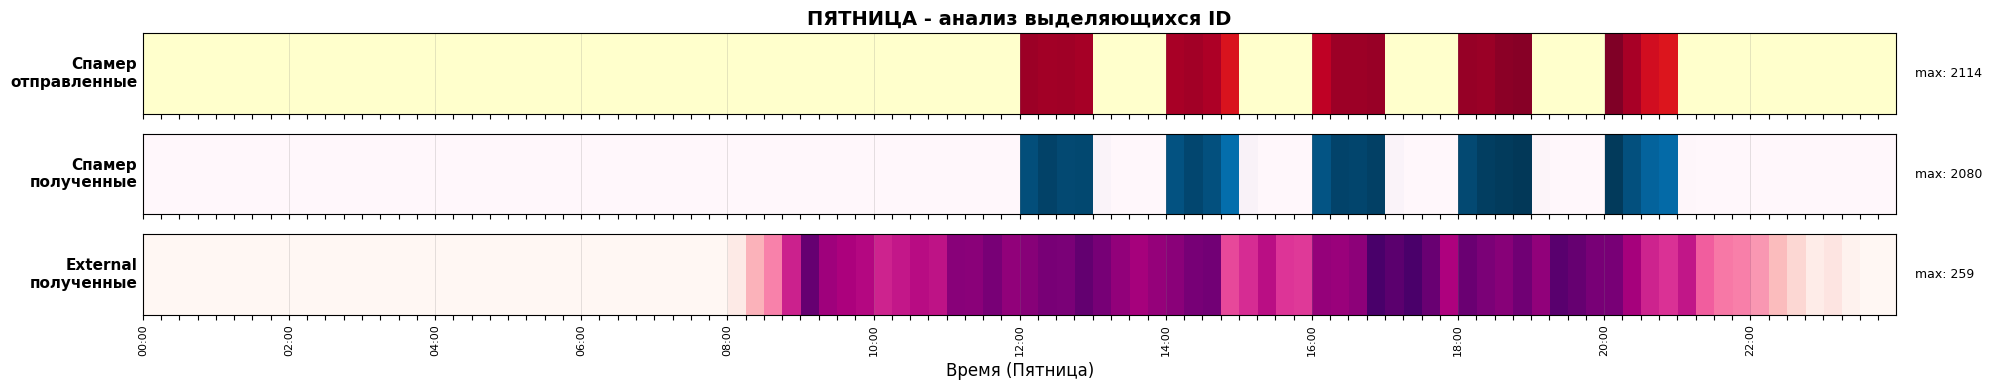

Пятница - спамер отправил: 2114, получил: 2080, external: 259


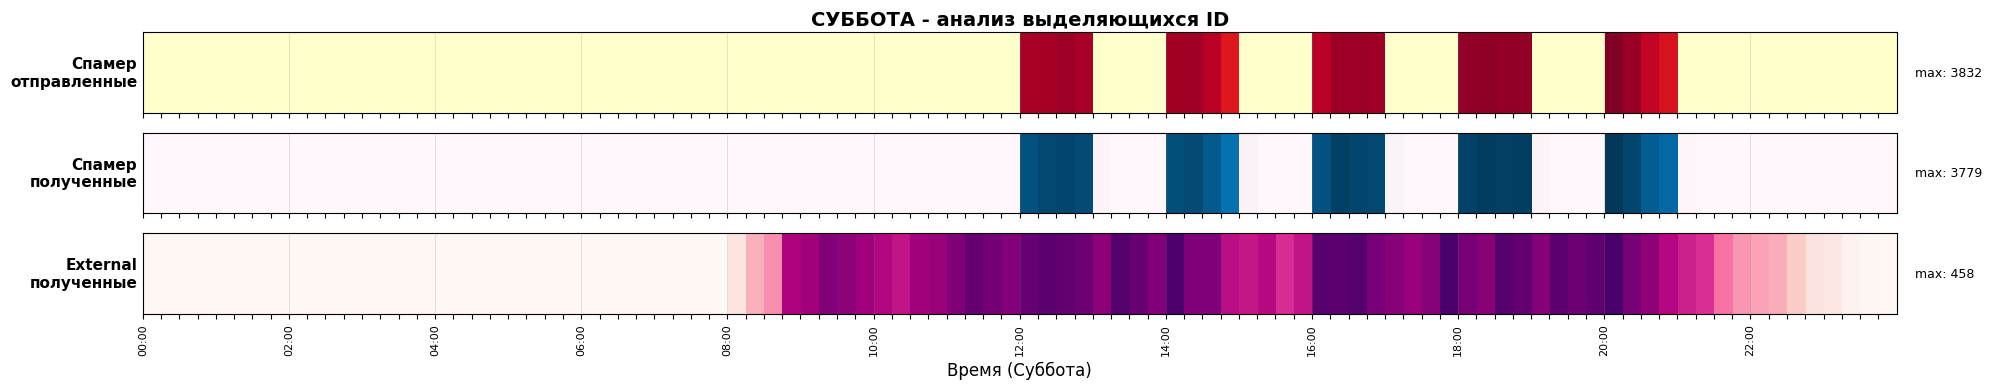

Суббота - спамер отправил: 3832, получил: 3779, external: 458


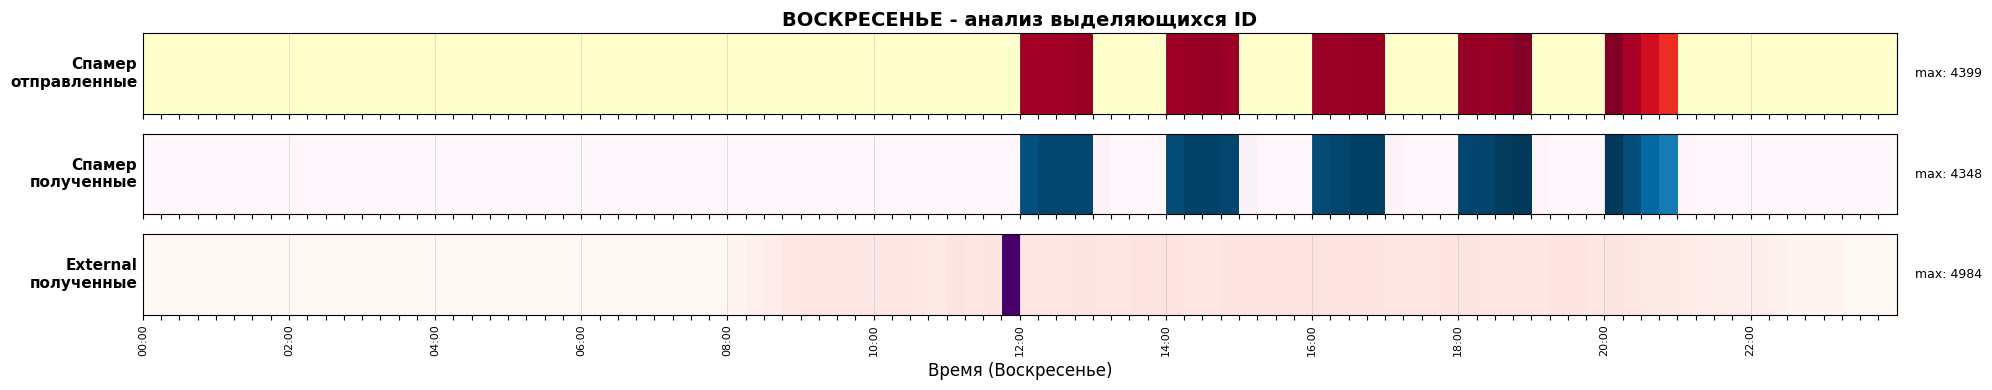

Воскресенье - спамер отправил: 4399, получил: 4348, external: 4984


In [47]:
import matplotlib.pyplot as plt

def plot_highlight_ids(df, day_name, intervals, clock_labels):
    fig, axes = plt.subplots(3, 1, figsize=(20, 4), sharex=True)

    # 1. Отправленные спамером (from = 1278894)
    df_spamer_sent = df[df["from"] == 1278894].copy()
    spamer_sent_counts = df_spamer_sent.groupby("quarter").size().reindex(intervals, fill_value=0)
    spamer_sent_max = spamer_sent_counts.max()
    spamer_sent_norm = spamer_sent_counts / spamer_sent_max if spamer_sent_max > 0 else spamer_sent_counts
    axes[0].imshow([spamer_sent_norm.values], cmap="YlOrRd", aspect="auto", extent=[1, 97, 0, 1])
    axes[0].set_yticks([])
    axes[0].set_ylabel("Спамер\nотправленные", fontsize=11, fontweight='bold', rotation=0, ha='right', va='center')
    axes[0].text(98, 0.5, f"max: {spamer_sent_max}", va='center', fontsize=9)
    axes[0].set_title(f"{day_name.upper()} - анализ выделяющихся ID", fontsize=14, fontweight='bold')

    # 2. Полученные спамером (to = '1278894')
    df_spamer_rec = df[df["to"] == "1278894"].copy()
    spamer_rec_counts = df_spamer_rec.groupby("quarter").size().reindex(intervals, fill_value=0)
    spamer_rec_max = spamer_rec_counts.max()
    spamer_rec_norm = spamer_rec_counts / spamer_rec_max if spamer_rec_max > 0 else spamer_rec_counts
    axes[1].imshow([spamer_rec_norm.values], cmap="PuBu", aspect="auto", extent=[1, 97, 0, 1])
    axes[1].set_yticks([])
    axes[1].set_ylabel("Спамер\nполученные", fontsize=11, fontweight='bold', rotation=0, ha='right', va='center')
    axes[1].text(98, 0.5, f"max: {spamer_rec_max}", va='center', fontsize=9)

    # 3. Полученные external
    df_external = df[df["to"] == "external"].copy()
    external_counts = df_external.groupby("quarter").size().reindex(intervals, fill_value=0)
    external_max = external_counts.max()
    external_norm = external_counts / external_max if external_max > 0 else external_counts
    axes[2].imshow([external_norm.values], cmap="RdPu", aspect="auto", extent=[1, 97, 0, 1])
    axes[2].set_yticks([])
    axes[2].set_ylabel("External\nполученные", fontsize=11, fontweight='bold', rotation=0, ha='right', va='center')
    axes[2].text(98, 0.5, f"max: {external_max}", va='center', fontsize=9)

    # Вертикальные линии для часов
    for ax in axes:
        for hour in range(0, 25, 2):
            quarter_pos = hour * 4 + 1
            if quarter_pos <= 97:
                ax.axvline(x=quarter_pos, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

    # Настройка нижней оси
    axes[2].set_xticks(intervals)
    axes[2].set_xticklabels(clock_labels, rotation=90, fontsize=8)
    axes[2].set_xlabel(f'Время ({day_name})', fontsize=12)

    plt.tight_layout()
    plt.show()

    print(f"{day_name} - спамер отправил: {spamer_sent_max}, получил: {spamer_rec_max}, external: {external_max}")


# Список дней и соответствующих df
days = [("Пятница", df_fri_processed),
        ("Суббота", df_sat_processed),
        ("Воскресенье", df_sun_processed)]

# Цикл по дням
for day_name, df_day in days:
    plot_highlight_ids(df_day, day_name, intervals, clock_labels)

## На шкалах можно заметить **второй паттерн**: рассылка по расписанию у id=1278894, **третий паттерн**: external соразмерно общей активности исключительно получает сообщения, но не отправляет (имеется всплеск в 12 часов в воскресенье, соответствует общему всплеску).

# Паттерн общения

In [48]:
# Функция для анализа сообществ одного дня
def analyze_day_communities(df_day, day_name):
    print(f"\n{'='*60}")
    print(f"АНАЛИЗ СООБЩЕСТВ - {day_name}")
    print('='*60)

    # Создаем граф для этого дня
    edges = df_day.groupby(["from", "to"]).size().reset_index(name="weight")

    G = nx.from_pandas_edgelist(
        edges,
        source="from",
        target="to",
        edge_attr="weight",
        create_using=nx.Graph()
    )

    print(f"Узлов: {G.number_of_nodes()}, Рёбер: {G.number_of_edges()}")

    # Поиск сообществ
    partition = community_louvain.best_partition(G, weight="weight")
    print(f"Найдено сообществ: {len(set(partition.values()))}")

    # Добавляем сообщества в датафрейм
    df_day = df_day.copy()
    df_day["from_comm"] = df_day["from"].map(partition)
    df_day["to_comm"] = df_day["to"].map(partition)

    # --- НАХОДИМ СПЕЦИАЛЬНЫЕ СООБЩЕСТВА ---

    external_comm = None
    if "external" in df_day["to"].values:
        ext_comms = df_day.loc[df_day["to"] == "external", "to_comm"].dropna().unique()
        external_comm = ext_comms[0] if len(ext_comms) > 0 else None

    spamer_comm = None
    if 1278894 in df_day["from"].values:
        spam_comms = df_day.loc[df_day["from"] == 1278894, "from_comm"].dropna().unique()
        spamer_comm = spam_comms[0] if len(spam_comms) > 0 else None

    user839736_comm = None
    if 839736 in df_day["from"].values:
        user_comms = df_day.loc[df_day["from"] == 839736, "from_comm"].dropna().unique()
        user839736_comm = user_comms[0] if len(user_comms) > 0 else None

    print(f"Сообщество external: {external_comm}")
    print(f"Сообщество спамера 1278894: {spamer_comm}")
    print(f"Сообщество пользователя 839736: {user839736_comm}")

    # Размеры сообществ
    community_sizes = df_day["from_comm"].value_counts()

    print(f"\nТоп-5 самых больших сообществ:")
    for comm, size in community_sizes.head(5).items():
        print(f"  Сообщество {comm}: {size} участников")

    # Внутренние сообщения
    internal_msgs = df_day[df_day["from_comm"] == df_day["to_comm"]].groupby("from_comm").size()

    # --- ГРАФ СООБЩЕСТВ ---
    G_comm = nx.Graph()

    group_edges = (
        df_day[df_day["from_comm"] != df_day["to_comm"]]
        .groupby(["from_comm", "to_comm"])
        .size()
        .reset_index(name="messages")
    )

    for _, row in group_edges.iterrows():
        G_comm.add_edge(row["from_comm"], row["to_comm"], messages=row["messages"])

    if len(G_comm.nodes()) == 0:
        print("Нет связей между сообществами")
        return df_day, partition

    # Размер узлов
    node_sizes = [np.log1p(community_sizes.get(n, 1)) * 100 for n in G_comm.nodes()]

    # Цвет узлов
    node_colors = [np.log1p(internal_msgs.get(n, 0)) for n in G_comm.nodes()]
    if max(node_colors) > 0:
        node_colors = np.array(node_colors) / max(node_colors)

    # --- ОБВОДКА УЗЛОВ ---
    edge_colors = []
    edge_widths = []

    for n in G_comm.nodes():

        if n == external_comm:
            edge_colors.append("red")
            edge_widths.append(3)

        elif n == spamer_comm:
            edge_colors.append("green")
            edge_widths.append(3)

        elif n == user839736_comm:
            edge_colors.append("orange")
            edge_widths.append(3)

        else:
            edge_colors.append("black")
            edge_widths.append(0.5)

    # Позиции на окружности
    n_nodes = len(G_comm.nodes())
    angles = np.linspace(0, 2*np.pi, n_nodes, endpoint=False)
    pos = {node: (np.cos(a), np.sin(a)) for node, a in zip(G_comm.nodes(), angles)}

    # Рисуем
    fig, ax = plt.subplots(figsize=(10, 10))

    nx.draw_networkx_nodes(
        G_comm,
        pos,
        node_size=node_sizes,
        node_color=node_colors,
        cmap=plt.cm.Blues,
        edgecolors=edge_colors,
        linewidths=edge_widths,
        ax=ax
    )

    nx.draw_networkx_edges(G_comm, pos, alpha=0.6, ax=ax)
    nx.draw_networkx_labels(G_comm, pos, font_size=9, ax=ax)

    # Цветовая шкала
    sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues, norm=plt.Normalize(0, 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("Интенсивность внутренних сообщений")

    # --- ЛЕГЕНДА ---
    legend_elements = []

    if external_comm is not None:
        legend_elements.append(
            mpatches.Circle((0,0), radius=5, facecolor="none", edgecolor="red", linewidth=3, label="External")
        )

    if spamer_comm is not None:
        legend_elements.append(
            mpatches.Circle((0,0), radius=5, facecolor="none", edgecolor="green", linewidth=3, label="Спамер 1278894")
        )

    if user839736_comm is not None:
        legend_elements.append(
            mpatches.Circle((0,0), radius=5, facecolor="none", edgecolor="orange", linewidth=3, label="Пользователь 839736")
        )

    ax.legend(handles=legend_elements, loc="upper right", title="Выделенные сообщества")

    ax.set_title(f"Граф сообществ - {day_name}")
    ax.axis("off")

    plt.tight_layout()
    plt.show()

    return df_day, partition


АНАЛИЗ СООБЩЕСТВ - ПЯТНИЦА
Узлов: 5876, Рёбер: 167760
Найдено сообществ: 41
Сообщество external: 17
Сообщество спамера 1278894: 12
Сообщество пользователя 839736: 12

Топ-5 самых больших сообществ:
  Сообщество 0: 100571 участников
  Сообщество 12: 69432 участников
  Сообщество 8: 67075 участников
  Сообщество 4: 64104 участников
  Сообщество 5: 63916 участников


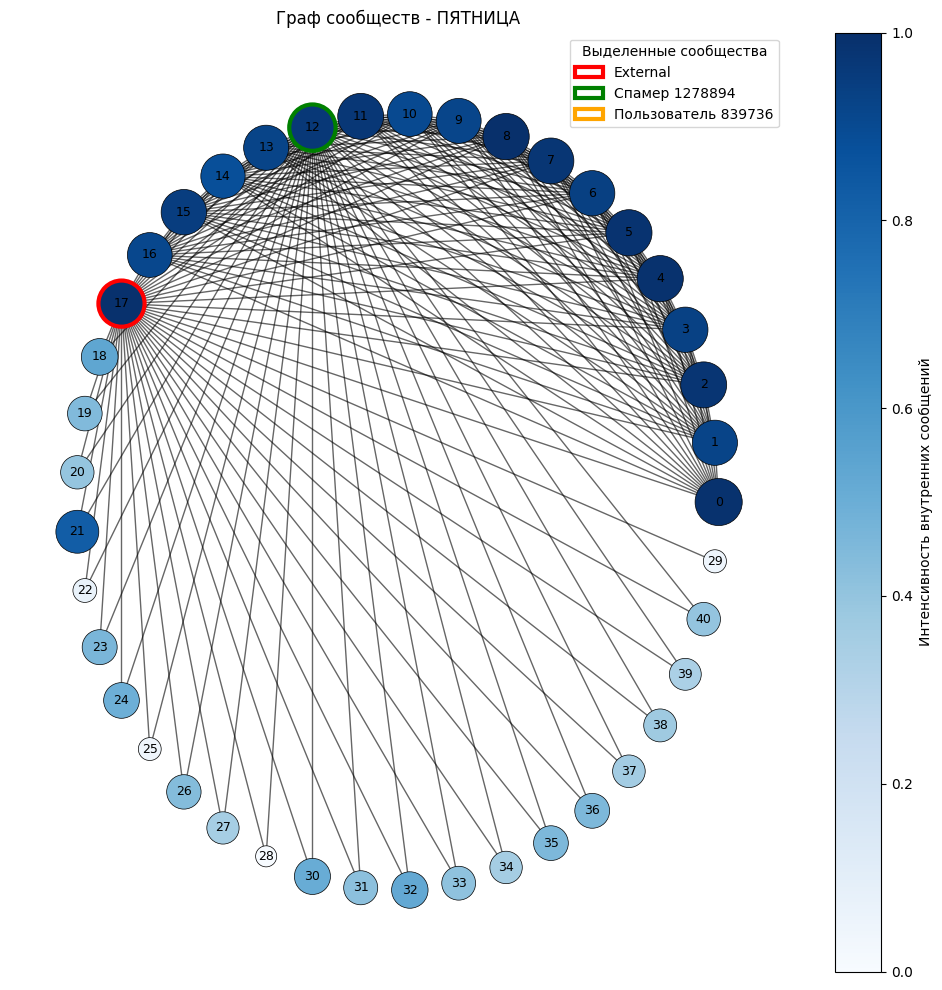


АНАЛИЗ СООБЩЕСТВ - СУББОТА
Узлов: 10525, Рёбер: 302824
Найдено сообществ: 111
Сообщество external: 4
Сообщество спамера 1278894: 18
Сообщество пользователя 839736: 18

Топ-5 самых больших сообществ:
  Сообщество 7: 204919 участников
  Сообщество 18: 142207 участников
  Сообщество 4: 137914 участников
  Сообщество 15: 71461 участников
  Сообщество 22: 63642 участников


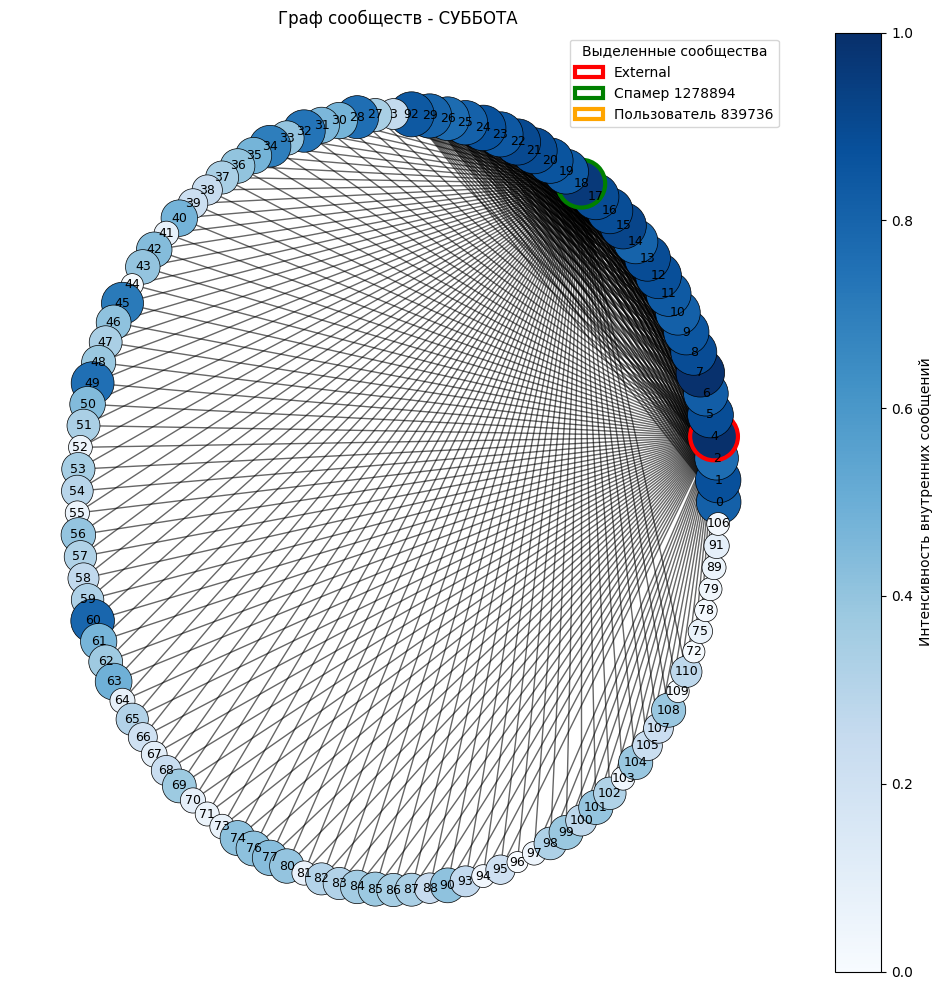


АНАЛИЗ СООБЩЕСТВ - ВОСКРЕСЕНЬЕ
Узлов: 12158, Рёбер: 276045
Найдено сообществ: 76
Сообщество external: 2
Сообщество спамера 1278894: 61
Сообщество пользователя 839736: 2

Топ-5 самых больших сообществ:
  Сообщество 24: 275654 участников
  Сообщество 2: 169184 участников
  Сообщество 61: 138406 участников
  Сообщество 1: 103039 участников
  Сообщество 10: 76974 участников


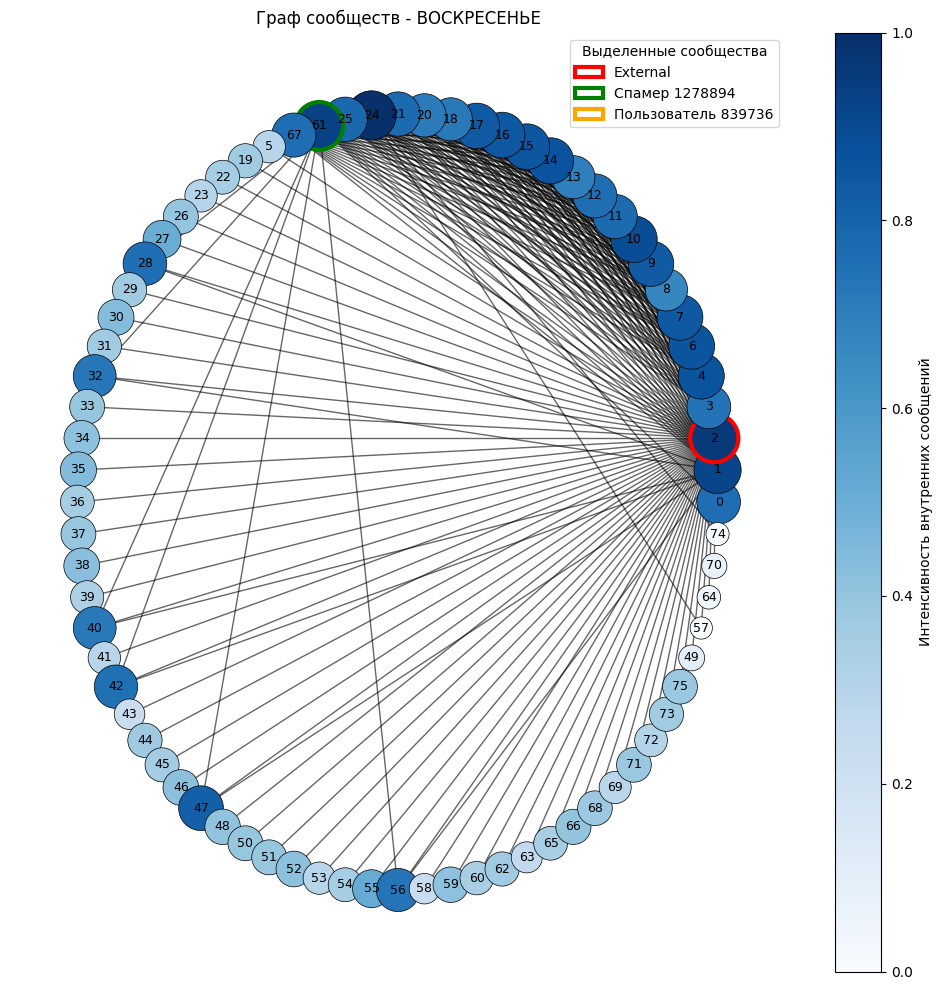

In [49]:
# анализ для каждого дня
# Пятница
df_fri_with_comm, partition_fri = analyze_day_communities(df_fri_processed, "ПЯТНИЦА")

# Суббота
df_sat_with_comm, partition_sat = analyze_day_communities(df_sat_processed, "СУББОТА")

# Воскресенье
df_sun_with_comm, partition_sun = analyze_day_communities(df_sun_processed, "ВОСКРЕСЕНЬЕ")

## На графах можно заметить **четвертый патерн**: большие группы много общаются межу собой, а маленькие - общаются только с группами-рассыльшиками, но не между собой. **Гипотеза**: большие группы - группы сотрудников, маленькие - посетителей.

# Паттерн плотности сообщений по локациям и времени (диаграмма Сэнкея)

In [52]:
import plotly.graph_objects as go
import pandas as pd

# Функция для категорий времени суток
def get_time_category(hour):
    if 5 <= hour < 12:
        return 'Утро (5-12)'
    elif 12 <= hour < 17:
        return 'День (12-17)'
    elif 17 <= hour < 22:
        return 'Вечер (17-22)'
    else:
        return 'Ночь (22-5)'

# Применяем к каждому дню
for df in [df_fri_processed, df_sat_processed, df_sun_processed]:
    df['time_category'] = df['hour'].apply(get_time_category)

# Функция построения Sankey
def plot_time_location_sankey(df, day_name):
    time_order = ['Утро (5-12)', 'День (12-17)', 'Вечер (17-22)', 'Ночь (22-5)']

    # Группировка: время → локация
    time_loc_flows = df.groupby(['time_category', 'location']).size().reset_index(name='count')

    # Упорядочим категории
    time_loc_flows['time_category'] = pd.Categorical(
        time_loc_flows['time_category'],
        categories=time_order,
        ordered=True
    )
    time_loc_flows = time_loc_flows.sort_values('time_category')

    # Узлы Sankey: сначала категории времени, потом локации
    locations = list(df['location'].unique())
    nodes = time_order + locations
    node_to_idx = {node: i for i, node in enumerate(nodes)}

    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=nodes,
            color=['lightblue']*4 + ['lightgreen']*len(locations)
        ),
        link=dict(
            source=[node_to_idx[row['time_category']] for _, row in time_loc_flows.iterrows()],
            target=[node_to_idx[row['location']] for _, row in time_loc_flows.iterrows()],
            value=time_loc_flows['count'],
            hovertemplate='%{source.label} → %{target.label}<br>Сообщений: %{value}<extra></extra>'
        )
    )])

    fig.update_layout(
        title=f"Распределение сообщений по времени суток и локациям в {day_name}",
        font_size=12,
        width=1000,
        height=600
    )

    fig.show()

# Создаем Sankey для каждого дня
plot_time_location_sankey(df_fri_processed, "Пятницу")
plot_time_location_sankey(df_sat_processed, "Субботу")
plot_time_location_sankey(df_sun_processed, "Воскресенье")

## По сравнению с одинаковым распределением активности в течение дня в пятницу и субботу, в воскресенье активность падает везде, кроме Wet Land и Tundra Land во время с 12 до 17 часов. Рассмотрим этот отрезок дня в воскресенье подробнее с помощью динамического графика

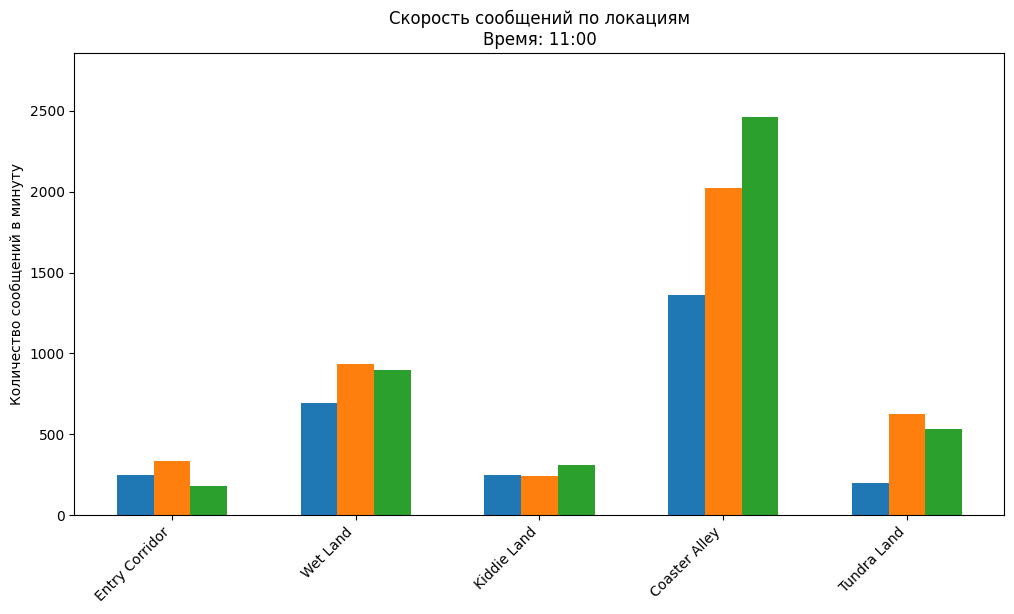

In [51]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import pandas as pd
from IPython.display import HTML
import numpy as np

# Функция подготовки данных (копия и минуты)
def prepare_day(df, day_name):
    df_day = df.copy()
    df_day['time_min'] = df_day['hour']*60 + df_day['minute']
    df_day['day'] = day_name
    return df_day

# Подготавливаем данные
df_fri_filtered = prepare_day(df_fri_processed[(df_fri_processed['hour'] >= 11) & (df_fri_processed['hour'] < 13)], 'Friday')
df_sat_filtered = prepare_day(df_sat_processed[(df_sat_processed['hour'] >= 11) & (df_sat_processed['hour'] < 13)], 'Saturday')
df_sun_filtered = prepare_day(df_sun_processed[(df_sun_processed['hour'] >= 11) & (df_sun_processed['hour'] < 13)], 'Sunday')

# Объединяем данные
df_all = pd.concat([df_fri_filtered, df_sat_filtered, df_sun_filtered], ignore_index=True)

# Локации и дни
locations = df_all['location'].unique()
days = ['Friday', 'Saturday', 'Sunday']
colors = {'Friday':'#1f77b4', 'Saturday':'#ff7f0e', 'Sunday':'#2ca02c'}

# Подготовка графика
fig, ax = plt.subplots(figsize=(12,6))
n_loc = len(locations)
width = 0.2  # ширина одного столбика
x = np.arange(n_loc)  # позиции для групп

# создаем пустые столбики для каждого дня
bars = {day: ax.bar(x + i*width, [0]*n_loc, width, color=colors[day]) for i, day in enumerate(days)}

ax.set_xticks(x + width)
ax.set_xticklabels(locations, rotation=45, ha='right')
ax.set_ylim(0, df_all.groupby(['day','location','time_min']).size().max() + 2)  # масштаб по максимуму за минуту
ax.set_ylabel('Количество сообщений в минуту')
ax.set_title('Скорость сообщений по локациям (11:00–13:00)')

# все уникальные минуты
times = sorted(df_all['time_min'].unique())

def update(frame):
    for i, day in enumerate(days):
        df_current = df_all[(df_all['time_min']==frame) & (df_all['day']==day)]
        counts = df_current['location'].value_counts()
        for bar, loc in zip(bars[day], locations):
            bar.set_height(counts.get(loc, 0))
    ax.set_title(f'Скорость сообщений по локациям\nВремя: {frame//60}:{frame%60:02d}')
    return [bar for day_bars in bars.values() for bar in day_bars]

ani = FuncAnimation(fig, update, frames=times, interval=200, repeat=False)

HTML(ani.to_jshtml())

## Самый заметный скачок сообщений наблюдается в Wet Land в 12-00, тогда же, когда и виден общий пик плотности сообщений. Это позволяет выдвинуть **гипотезу** о том, что преступление произошло в Wet Land в рацоне 12 часов утра.